<a href="https://colab.research.google.com/github/Numpaque4/pryngles-numpaque/blob/kiss/doc/tests/areas_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Test for Areas Normalization**

In [ ]:
!pip install -q git+https://github.com/Numpaque4/pryngles-numpaque

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install pyppluss

In [ ]:
import numpy as np
import pandas as pd
import pryngles as pr
import plotly.graph_objects as go
from pyppluss.segment_models import LC_ringed

%matplotlib inline

## **System Parameters**

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 74.6*pr.DEG #Deg
roll = (90 - 56.9)*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

## **Building System**

In [ ]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um, nspangles = 100,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul, nspangles = 100,
                    m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe, nspangles = 100,
                  i = i_ring, roll = roll - np.pi/2)

In [ ]:
system.initialize_simulation()
system.spangle_system()

## `normalize_areas()` **Method Validation**

In [ ]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*planet.radius**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 1.3124542436524663e-08
Facet-Based Area: 1.3124542436524668e-08
Normalization Factor: 0.9999999999999997


In [ ]:
cond_ring = (system.data.name == 'Ring')*(system.data.cos_obs >= 0)

expected_area = np.pi*(ring.re**2 - ring.ri**2)*system.data.cos_obs[cond_ring].iloc[0]

facet_area = (system.data.asp_obs[cond_ring]*system.data.cos_obs[cond_ring]).sum()

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 1.4161618806946275e-07
Facet-Based Area: 1.4161618806946248e-07
Normalization Factor: 1.0000000000000018


# `pr.System` - `pypPlusS` **Areas Validation**

In [ ]:
from pyppluss.segment_models import tot_hidden_area, planet_hidden_area
from pyppluss.base_functions import get_disk_planet_intersection, get_star_disk_intersection, get_star_planet_intersection, coord_swap

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 7.037276e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = 0*pr.DEG #Deg
roll = (90 - 0)*pr.DEG #Deg
fi, fe = 1, 1 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

## **Planet Hidden Area Validation**

In [ ]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = e, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul,
                    m = 0)

In [ ]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

In [ ]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*(planet.radius/star.radius)**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.015558188937801788
Facet-Based Area: 0.015558188937801785
Normalization Factor: 1.0000000000000002


In [ ]:
rhos_system = system.data.center_obs.iloc[-1][:2]/star.radius

x_star, y_star = coord_swap([rhos_system[0]],[rhos_system[1]], roll)

pyp_planet_area = planet_hidden_area(radius_planet = np.array([Rp/Rs]), x_star = x_star, y_star = y_star, tol=1e-10,
                                     star_planet_intersections = get_star_planet_intersection(x_star, y_star, np.array([Rp/Rs]), 1e-10))

print(f'pypPlusS Planet Hidden Area: {pyp_planet_area}')

pypPlusS Planet Hidden Area: [0.01555819]


## **Ring Hidden Area Validation**

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = np.pi/2 #74.6*pr.DEG #Deg
roll = 0*(90 - 56.9)*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

In [ ]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul,
                    m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe,
                  i = i_ring, roll = roll)

In [ ]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

(0, 0)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

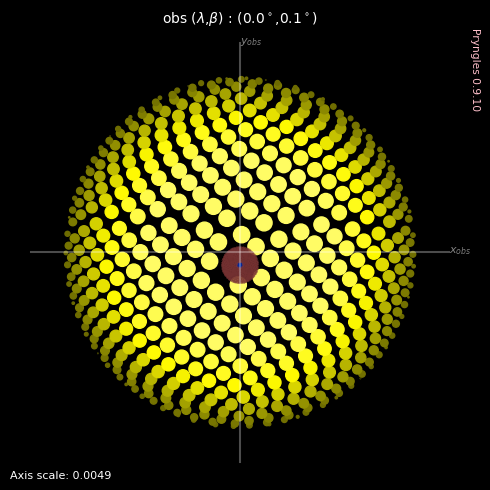

In [ ]:
system.sg.plot2d()

In [ ]:
cond_planet = (system.data.name == 'Planet')*(system.data.cos_obs >= 0)

expected_area = np.pi*(planet.radius/star.radius)**2

facet_area = (system.data.asp_obs[cond_planet]*system.data.cos_obs[cond_planet]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.0008024512300158876
Facet-Based Area: 0.0008024512300158868
Normalization Factor: 1.0000000000000009


In [ ]:
cond_ring = (system.data.name == 'Ring')*(~system.data.hidden)

expected_area = np.pi*(ring.re**2 - ring.ri**2)/star.radius**2

facet_area = (system.data.asp_obs[cond_ring]).sum()/star.radius**2

print(f'Expected Area: {expected_area}\nFacet-Based Area: {facet_area}\nNormalization Factor: {expected_area/facet_area}')

Expected Area: 0.03260551508021998
Facet-Based Area: 0.032605515080219825
Normalization Factor: 1.0000000000000047


In [ ]:
R_planet = np.array([Rp/Rs])

rhos_system = system.data.center_obs.iloc[-1][:2]/star.radius

x_star, y_star = coord_swap([rhos_system[0]],[rhos_system[1]], roll)

pyp_planet_area = planet_hidden_area(radius_planet = np.array([Rp/Rs]), x_star = x_star, y_star = y_star, tol=1e-10,
                                     star_planet_intersections = get_star_planet_intersection(x_star, y_star, np.array([Rp/Rs]), 1e-10))

total_area = tot_hidden_area(radius_planet = R_planet, radius_in = fi*R_planet, radius_out = fe*R_planet,
                            x_star = x_star, y_star = y_star, ring_inclination = np.pi/2 - i_ring, opacity = 1, tol=1e-10,
                            star_planet_intersections = get_star_planet_intersection(x_star, y_star, R_planet, 1e-10),
                            star_disk_intersections_in = get_star_disk_intersection(x_star, y_star, fi*R_planet, np.pi/2 - i_ring, 1e-10),
                            star_disk_intersections_out = get_star_disk_intersection(x_star, y_star, fe*R_planet, np.pi/2 - i_ring, 1e-10),
                            disk_planet_intersections_in = get_disk_planet_intersection(R_planet, fi*R_planet, np.pi/2 - i_ring, 1e-10),
                            disk_planet_intersections_out = get_disk_planet_intersection(R_planet, fe*R_planet, np.pi/2 - i_ring, 1e-10))

print(f'pypPlusS Planet Hidden Area: {pyp_planet_area}\npypPlusS Ring Hidden Area: {total_area - pyp_planet_area}')

pypPlusS Planet Hidden Area: [0.00080245]
pypPlusS Ring Hidden Area: [0.03260552]


# **Light Curve Test**

In [ ]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
i_ring = np.pi/2 #74.6*pr.DEG #Deg
roll = 0*(90 - 56.9)*pr.DEG #Deg
fi, fe = 1, 6.452317 #Rplanet

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = 89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

## **RingedPlanet**

In [ ]:
RP = pr.RingedPlanet(Nb = 0, Np = 987, Ns = 987, Nr = 1000,
                     Rint = fi, Rext = fe,
                     a = a, e = e, i = i_ring,
                     Rstar = Rs/pr.Consts.au,
                     Rplanet = Rp/pr.Consts.au,
                     Mstar = Ms/pr.Consts.msun,
                     eobs_ecl = [np.pi/2 + roll, np.pi/2 - inc],
                     physics = dict(limb_cs = limb_cf))

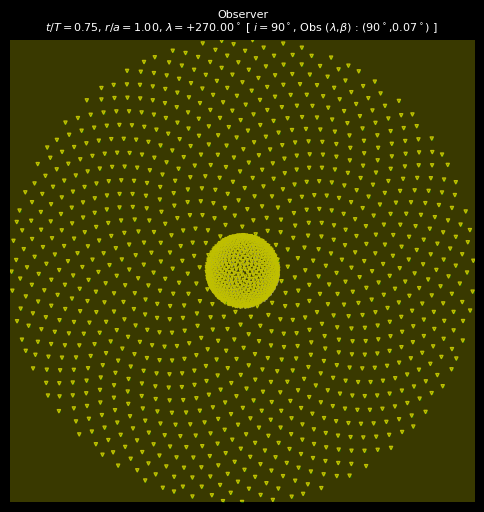

In [ ]:
RP.changeStellarPosition(3*np.pi/2 + roll, kepler = False)
RP.plotRingedPlanet(showfig = False, showstar = True, axis = False)[1]

In [ ]:
#Transit Interval
lambdas = np.linspace(3*np.pi/2 + roll - 1.5*(RP.thetas + RP.thetap),
                      3*np.pi/2 + roll + 1.5*(RP.thetas + RP.thetap), 100)

ts = np.zeros_like(lambdas)
# rhos = np.zeros((100, 2))

RP.taur = np.inf

# Flux Values for Planet and Ring
transit_RP = np.zeros((100, 2))

# Integrating
for i, lam in enumerate(lambdas):

  # Integrating on time domain for RingedPlanet
  RP.changeStellarPosition(lam, kepler = False)
  ts[i] = RP.t*RP.CU.UT
  # rhos[i] = RP.rstar_obs[:2]

  # Computing Transit for RingedPlanet
  RP.updateOpticalFactors()
  RP.updateTransit()

  # Values for every Time-Step
  transit_RP[i] = [RP.Tip.sum(), RP.Tir.sum()]

## **System**

In [ ]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, i = (90 - inc)*pr.DEG,
                    radius = Rp/system.ul,
                    m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe,
                  i = i_ring, roll = roll)

In [ ]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

(0, 0)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

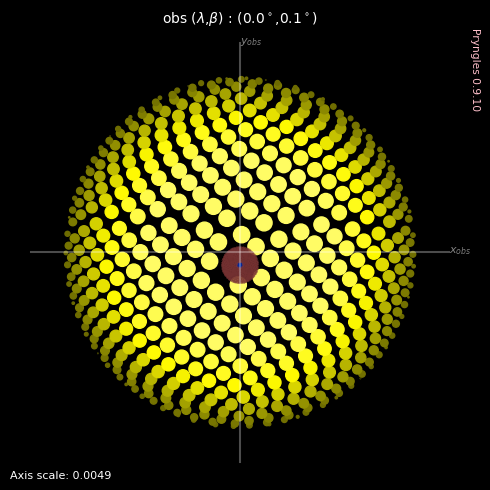

In [ ]:
system.sg.plot2d()

In [ ]:
taur_values = {name: np.inf #system.bodies[name].taur
              #  if system.bodies[name].kind == 'Ring'
              #  else np.inf
               for name in system.bodies}

system.data.tau_gray_optical = system.data.name.map(taur_values)

In [ ]:
# ts = np.linspace(-3e-3, 3e-3, 100)

# Flux Values for Planet and Ring
transit_system = np.zeros((100, 2))
rhos_system = np.zeros((100, 2))

# Integrating
for i, t in enumerate((ts - ts.mean())/system.ut):

  # Integration for System
  system.integrate_perspective(t)
  system.update_Transit()

  # Values for every Time-Step
  transit_system[i] = pd.Series(system.data.transit_flux.values,
                                index = system.data.name
                                ).groupby('name').sum()[:2]

  rhos_system[i] = system.data.center_obs.iloc[-1][:2]/star.radius

In [ ]:
R_planet = Rp/Rs*np.ones(100)

pyplus_flux = LC_ringed(radius_planet = R_planet, radius_in = fi*R_planet,
                        radius_out = fe*R_planet, x_planet = rhos_system[:,0], y_planet = rhos_system[:,1],
                        ring_inclination = np.pi/2 - i_ring, ring_rotation = roll,
                        opacity = opacity, c1 = 0,c2 = limb_cf[0], c3 = '0', c4 = limb_cf[1])

In [ ]:
go.Figure([go.Scatter(x = (ts - ts.mean())/pr.Const.hours,
                      y = 1 - transit_RP.sum(axis = 1),
                      name = 'RP',
                      showlegend = True),
           go.Scatter(x = (ts - ts.mean())/pr.Const.hours,
                      y = 1 - transit_system.sum(axis = 1),
                      name = 'System',
                      showlegend = True),
          go.Scatter(x = (ts - ts.mean())/pr.Const.hours,
                      y = pyplus_flux,
                      name = 'pyPplusS',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Normalized Flux',
                             title_text = 'Planet-Ring Model Light Curve<br>( System )',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.78)))

In [ ]:
go.Figure([go.Scatter(x = (ts - ts.mean())/pr.Const.hours,
                      y = (1 - transit_system.sum(axis = 1) - pyplus_flux)*100/pyplus_flux,
                      name = 'Sys/pyp',
                      showlegend = True),
           go.Scatter(x = (ts - ts.mean())/pr.Const.hours,
                      y = (pyplus_flux - 1 + transit_RP.sum(axis = 1))*100/pyplus_flux,
                      name = 'RP/pyp',
                      showlegend = True)],

          layout = go.Layout(width = 900, height = 600,
                             title_x = 0.5, title_y = 0.95,
                             xaxis_title = 't [h]',
                             yaxis_title = 'Error [%]',
                             title_text = 'Planet/Ring-Model Light Curve Error',
                             legend = dict(orientation = 'h',
                                           y = 1.08, x = 0.75)))